In [1]:
# Cell 1 — Autoreload only
%load_ext autoreload
%autoreload 2

In [3]:
# Cell 1.5 - setup env
import sys
from pathlib import Path
sys.path.append(str(next(p for p in Path().resolve().parents if (p / "src").exists()) / "src"))

import setup_env
_ = setup_env.initialize_environment()

In [4]:
# Cell 2 — Imports
import re
import api_handler
import metrics
import cs_analysis
import sync

In [5]:
# Cell 3 — Environment + single puuid fetch
env = setup_env.initialize_environment()
repo_root = env["repo_root"]

SUMMONER_NAME = "RainbowThenga#420"
clean_name = re.sub(r'[^a-zA-Z0-9]', '_', SUMMONER_NAME)
BASE_DATA_PATH = repo_root / "data" / "users"
USER_DATA_PATH = BASE_DATA_PATH / clean_name

# Fetch puuid once — reuse everywhere
PUUID = api_handler.get_summoner_info(SUMMONER_NAME)["puuid"]

In [6]:
# Cell 4 — Sync
sync.sync_user_data(
    summoner_name=SUMMONER_NAME,
    base_data_path=BASE_DATA_PATH,
    champion_name=None,
    start_time=None,
    end_time=None,
)


📥 Syncing data for summoner: RainbowThenga#420
   Champion filter: None
🔍 Found 1 new matches to check.
→ Checking match EUW1_7748938705 for filters...
   Skipped (not Ranked Solo).
No new matches to download timelines for.
↪ Champion mastery already exists. Skipping.

✅ Sync complete.



In [7]:
# Cell 5 — Champion counts
metrics.champ_counts(summoner_riot_id=SUMMONER_NAME, repo_root=repo_root)

Counter({'Aphelios': 62,
         'Kalista': 6,
         'Senna': 2,
         'Rakan': 2,
         'Jhin': 1,
         'Kaisa': 1,
         'Lulu': 1,
         'Pantheon': 1,
         'Ashe': 1})

In [8]:
# Cell 6 — Recent matchup summaries
metrics.summarize_recent_matchups(
    summoner_name=SUMMONER_NAME,
    user_data_path=USER_DATA_PATH,
    num_matches=10,
)

🧾 Last 10 matchups for RainbowThenga#420:

EUW1_7784209161:     You: Aphelios + Brand
EUW1_7784174755:     You: Ashe + TahmKench
EUW1_7779347750:     You: Aphelios + Chogath
EUW1_7778223659:     You: Aphelios + Rakan
EUW1_7778159705:     You: Aphelios + Lulu
EUW1_7778085397:     You: Aphelios + Brand
EUW1_7778061434:     You: Aphelios + Thresh
EUW1_7778011483:     You: Aphelios + Lulu
EUW1_7777855090:     You: Aphelios + Pyke
EUW1_7777790734:     You: Aphelios + Soraka


In [10]:
# Cell 7 — Single match summary
match_id = "EUW1_7784209161"
summary = metrics.summarize_match_for_notes(match_id, SUMMONER_NAME, USER_DATA_PATH)
print(summary)

## Match Summary: EUW1_7784209161

Champion: Aphelios
KDA: 14/3/5
CS: 225 (6.4/min), CS@15: 121 (8.07/min)
Damage Dealt: 39,400 (Rank 2/10)

Bot Lane:

    You: Aphelios + Brand

    Enemy: Twitch + Taric

Result: Win
Game Duration: 35 min

Tags: #leagueoflegends #adc #champ-Aphelios #ally-champ-Brand #opp-champ-Twitch #opp-champ-Taric #win-yes




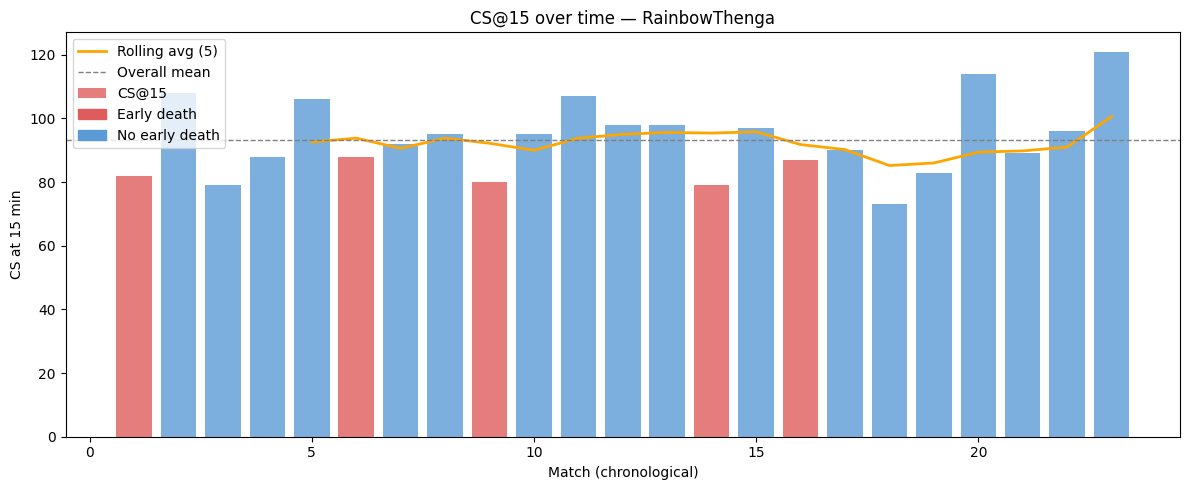

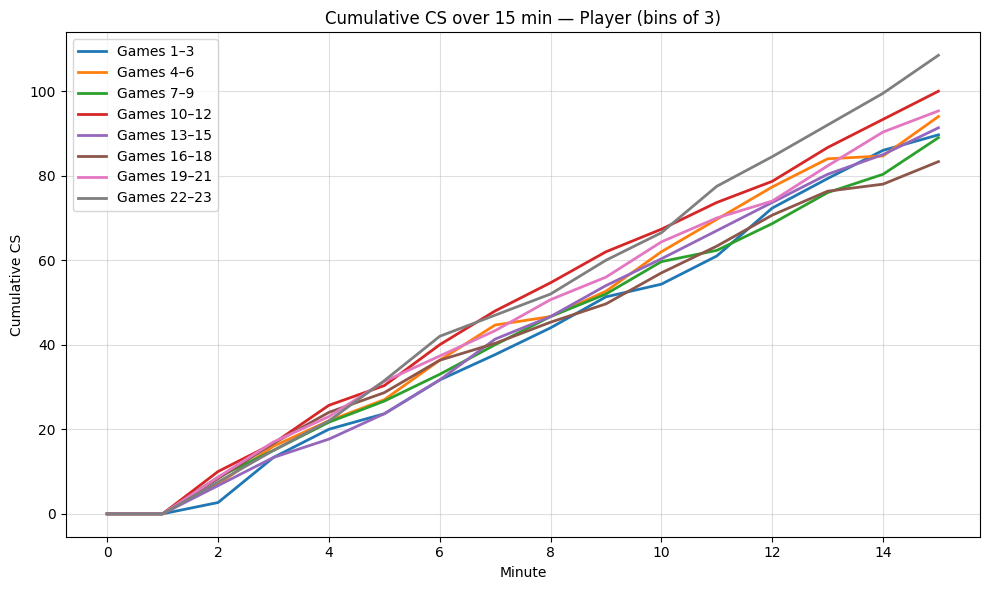

In [16]:
# Cell 8 — CS timeline (pass PUUID directly, no API call)
from api_handler import get_summoner_info
from cs_analysis import collect_cs_stats, plot_cs_at_15, plot_cumulative_cs_curves

puuid = get_summoner_info("RainbowThenga#420")["puuid"]
df = collect_cs_stats(puuid, USER_DATA_PATH, num_matches=30, champion_filter="Aphelios", early_death_before_minute=5)

plot_cs_at_15(df, summoner_name="RainbowThenga", rolling_window=5)
plot_cumulative_cs_curves(df, bin_size=3)